In [40]:
import pandas as pd


In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [43]:
iris=pd.read_csv("/content/drive/MyDrive/iris_dataset.csv")

In [44]:
iris.isna().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


In [45]:
from sklearn.preprocessing import MinMaxScaler

numeric_columns = iris.select_dtypes(include=['int64', 'float64']).column

scaler = MinMaxScaler()
iris[numeric_columns] = scaler.fit_transform(iris[numeric_columns])
iris.to_csv("normalized_data.csv", index=False)

print(iris.head())

AttributeError: 'DataFrame' object has no attribute 'column'

In [46]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
iris["target"]=label_encoder.fit_transform(iris["target"])

In [47]:
x=iris.drop("target",axis=1)
y=iris["target"]

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [49]:
x=iris.drop("target",axis=1)
y=iris["target"]

In [50]:
from sklearn.linear_model import LinearRegression

In [51]:
lr=LinearRegression()
lr

LinearRegression()

In [52]:
model=lr.fit(x_train,y_train)
model

LinearRegression()

In [53]:
y_pred=pd.DataFrame(lr.predict(x_test))
y_pred

,0
0,1.230517
1,-0.040888
2,2.221623
3,1.349720
4,1.286079
5,0.023466
6,1.057962
7,1.825570
8,1.372193
9,1.068988


In [54]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [55]:
ytestpred=model.predict(x_test)
ytestpred

array([ 1.2305166 , -0.04088817,  2.22162345,  1.34972015,  1.28607917,
        0.02346565,  1.05796175,  1.82557039,  1.37219259,  1.06898774,
        1.6997677 , -0.0725704 , -0.15476151, -0.06513544, -0.02320247,
        1.39524413,  1.99939235,  1.04970178,  1.28040501,  1.97315432,
        0.03134273,  1.59775615,  0.09419949,  1.91821542,  1.83026281,
        1.88002641,  1.78919243,  2.03257165,  0.0373074 ,  0.02643301])

In [56]:
ytrainpred=model.predict(x_train)
ytrainpred

array([-0.13469134, -0.07522241,  1.17702637,  0.00705787, -0.01033731,
        1.68751219,  1.28487263, -0.07013434, -0.07911796, -0.1638235 ,
        1.75669736,  1.37236716,  1.30774959, -0.05934912, -0.10578729,
        0.96206647,  1.47364288,  1.70876213,  1.19485284,  2.12166644,
        1.19816231,  2.02149591,  1.38873416, -0.08402768,  1.99336711,
        1.00963281, -0.0889374 , -0.04298212,  0.1327822 ,  0.99421759,
        1.59439509,  0.0828422 ,  0.01015519,  0.16949011,  1.22244716,
       -0.05230786,  1.13676503,  2.03866114, -0.00781206,  1.16658326,
        1.81065968, -0.17470871,  1.58386281,  1.75669736,  0.99392706,
        1.41147036,  1.96155627,  1.20912588,  0.04169665,  0.92431957,
        1.73901166, -0.05974283, -0.10380733,  1.04226682,  1.4998701 ,
       -0.06513544,  2.0249335 , -0.04093976,  0.19761891,  1.58231415,
        0.87918929,  1.97068067,  1.56914446,  1.58066414,  1.99369841,
        1.19620913,  0.03429927, -0.09151424,  1.521236  ,  1.73

In [57]:
mse=mean_squared_error(y_test,y_pred)
mse


0.03723364456197505

In [58]:
mae=mean_absolute_error(y_test,y_pred)
mae

0.1466990776263419

In [59]:
r2_score=r2_score(y_test,y_pred)
r2_score

0.9467245149351708

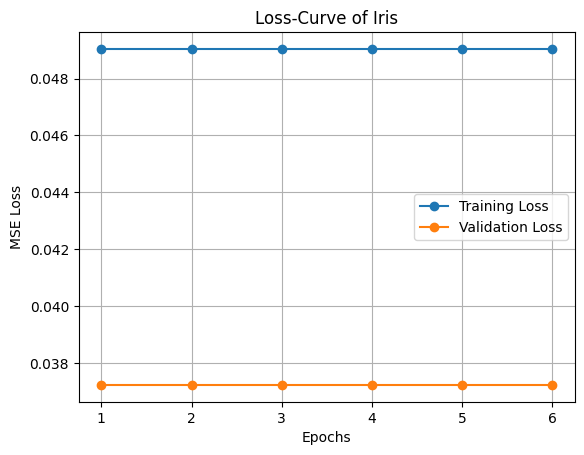

In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

train_losses = []
val_losses = []

for i in range(6):
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    train_losses.append(mean_squared_error(y_train, y_train_pred))
    val_losses.append(mean_squared_error(y_test, y_test_pred))

epochs = range(1, 7)

plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Loss-Curve of Iris')

plt.legend()
plt.grid(True)

plt.show()

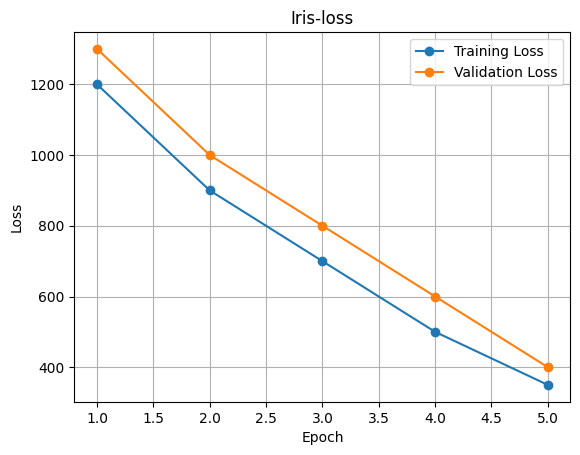

In [61]:
train_loss = [1200, 900, 700, 500, 350]
val_loss = [1300, 1000, 800, 600, 400]

epochs = range(1, 6)

plt.plot(epochs, train_loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Iris-loss')
plt.legend()
plt.grid(True)

plt.show()